# Individual Differences Analysis

Examines per-participant and per-model variation in performance:
- Individual accuracy across conditions
- Identify strong/weak performers
- Participant×Condition interactions
- Performance heterogeneity within domains

**Prerequisites:** Run `Data-Preparation.ipynb` first.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd() / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from src.data_loaders import load_human_master, load_model_master
from src.config import get_paths

paths = get_paths()
sns.set_style("whitegrid")

human_master = load_human_master()
model_master = load_model_master()

print(f"✓ Humans: {human_master['participantID'].nunique()} participants")
print(f"✓ Models: {model_master['participantID'].nunique()} models")

✓ Humans: 12 participants
✓ Models: 12 models


## 1. Individual Performance Summary

In [2]:
def compute_individual_metrics(df, domain_name):
    """Compute accuracy and SDT metrics per participant."""
    rows = []
    
    for pid in df['participantID'].unique():
        pdf = df[df['participantID'] == pid]
        
        for cond in df['condition'].unique():
            cpdf = pdf[pdf['condition'] == cond]
            if len(cpdf) == 0:
                continue
            
            # Compute metrics
            accuracy = (cpdf['decision'] == cpdf['TP']).mean()
            hits = np.sum((cpdf['decision'] == 1) & (cpdf['TP'] == 1))
            fas = np.sum((cpdf['decision'] == 1) & (cpdf['TP'] == 0))
            n_signal = np.sum(cpdf['TP'] == 1)
            n_noise = np.sum(cpdf['TP'] == 0)
            
            H = (hits + 0.5) / (n_signal + 1) if n_signal > 0 else np.nan
            F = (fas + 0.5) / (n_noise + 1) if n_noise > 0 else np.nan
            
            if np.isfinite(H) and np.isfinite(F):
                zH = norm.ppf(H)
                zF = norm.ppf(F)
                dprime = zH - zF
                criterion = -0.5 * (zH + zF)
            else:
                dprime = np.nan
                criterion = np.nan
            
            rows.append({
                "domain": domain_name,
                "participantID": pid,
                "condition": cond,
                "n_trials": len(cpdf),
                "accuracy": accuracy,
                "hit_rate": H,
                "fa_rate": F,
                "dprime": dprime,
                "criterion": criterion
            })
    
    return pd.DataFrame(rows)

human_indiv = compute_individual_metrics(human_master, "Human")
model_indiv = compute_individual_metrics(model_master, "Model")

indiv_all = pd.concat([human_indiv, model_indiv], ignore_index=True)

print("Human Individual Performance:")
display(human_indiv.sort_values("accuracy", ascending=False).head(10))

print("\nModel Individual Performance:")
display(model_indiv.sort_values("accuracy", ascending=False).head(15))

Human Individual Performance:


,domain,participantID,condition,n_trials,accuracy,hit_rate,fa_rate,dprime,criterion
26,Human,UR,100_0,1000,0.874,0.869261,0.122754,2.284234,0.019210
14,Human,KM,100_0,1000,0.789,0.701597,0.124750,1.680561,0.311282
5,Human,AG,100_0,1000,0.775,0.881238,0.332335,1.614670,-0.373861
11,Human,JH,100_0,1000,0.712,0.733533,0.310379,1.118309,-0.064379
3,Human,AG,50_50,1000,0.704,0.921158,0.513972,1.377872,-0.723966
13,Human,KM,80_20,1000,0.703,0.639721,0.234531,1.081718,0.183147
29,Human,HG,100_0,1000,0.691,0.691617,0.310379,0.995214,-0.002831
9,Human,JH,50_50,1000,0.683,0.509980,0.144711,1.084411,0.517187
12,Human,KM,50_50,1000,0.671,0.599800,0.258483,0.900860,0.197599
17,Human,AW,100_0,1000,0.657,0.743513,0.430140,0.830232,-0.239098



Model Individual Performance:


,domain,participantID,condition,n_trials,accuracy,hit_rate,fa_rate,dprime,criterion
17,Model,0responses_gemini-2.5-pro,100_0,1000,0.890,0.927146,0.148703,2.496872,-0.206422
35,Model,gemini-2.5-pro,100_0,1000,0.871,0.969062,0.228543,2.610835,-0.561764
33,Model,gemini-2.5-pro,50_50,1000,0.865,0.915170,0.186627,2.263691,-0.241450
5,Model,0responses_claude-3-7-sonnet-20250219,100_0,1000,0.850,0.835329,0.136727,2.070587,0.059852
4,Model,0responses_claude-3-7-sonnet-20250219,80_20,1000,0.847,0.833333,0.140719,2.044518,0.054838
34,Model,gemini-2.5-pro,80_20,1000,0.845,0.943114,0.254491,2.241886,-0.460519
23,Model,0responses_gpt-5-2025-08-07,100_0,1000,0.839,0.933134,0.256487,2.153758,-0.422665
29,Model,0responses_o3-2025-04-16,100_0,1000,0.836,0.937126,0.266467,2.154618,-0.453776
14,Model,0responses_gemini-2.5-flash,100_0,1000,0.831,0.875250,0.214571,1.942223,-0.180451
15,Model,0responses_gemini-2.5-pro,50_50,1000,0.823,0.921158,0.276447,2.006331,-0.409736


## 2. Performance Variability by Domain

In [3]:
# Summary statistics
for domain in ["Human", "Model"]:
    df = indiv_all[indiv_all["domain"] == domain]
    print(f"\n{domain}:")
    print(f"  Accuracy: mean={df['accuracy'].mean():.3f}, std={df['accuracy'].std():.3f}")
    print(f"  d': mean={df['dprime'].mean():.3f}, std={df['dprime'].std():.3f}")
    print(f"  Min accuracy: {df['accuracy'].min():.3f}")
    print(f"  Max accuracy: {df['accuracy'].max():.3f}")


Human:
  Accuracy: mean=0.611, std=0.092
  d': mean=0.647, std=0.556
  Min accuracy: 0.464
  Max accuracy: 0.874

Model:
  Accuracy: mean=0.770, std=0.067
  d': mean=1.636, std=0.463
  Min accuracy: 0.594
  Max accuracy: 0.890


## 3. Participant × Condition Heatmap

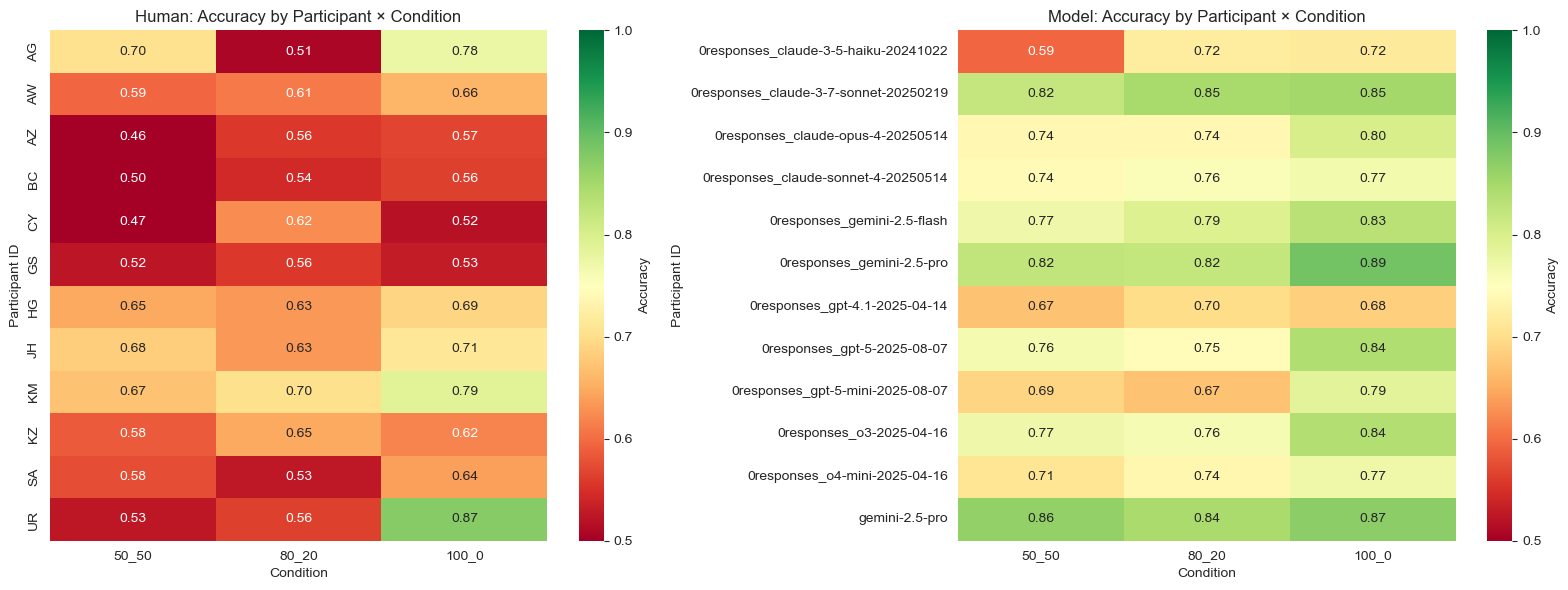

✓ Saved: individual-differences-heatmap.pdf


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, domain in zip(axes, ["Human", "Model"]):
    df = indiv_all[indiv_all["domain"] == domain]
    pivot = df.pivot(index="participantID", columns="condition", values="accuracy")
    pivot = pivot[["50_50", "80_20", "100_0"]]  # reorder columns
    
    sns.heatmap(
        pivot,
        annot=True,
        fmt=".2f",
        cmap="RdYlGn",
        vmin=0.5,
        vmax=1.0,
        ax=ax,
        cbar_kws={"label": "Accuracy"}
    )
    ax.set_title(f"{domain}: Accuracy by Participant × Condition", fontsize=12)
    ax.set_xlabel("Condition")
    ax.set_ylabel("Participant ID")

plt.tight_layout()
plt.savefig(paths.outputs_dir / "individual-differences-heatmap.pdf", bbox_inches="tight")
plt.show()

print("✓ Saved: individual-differences-heatmap.pdf")

## 4. Accuracy Distribution by Domain

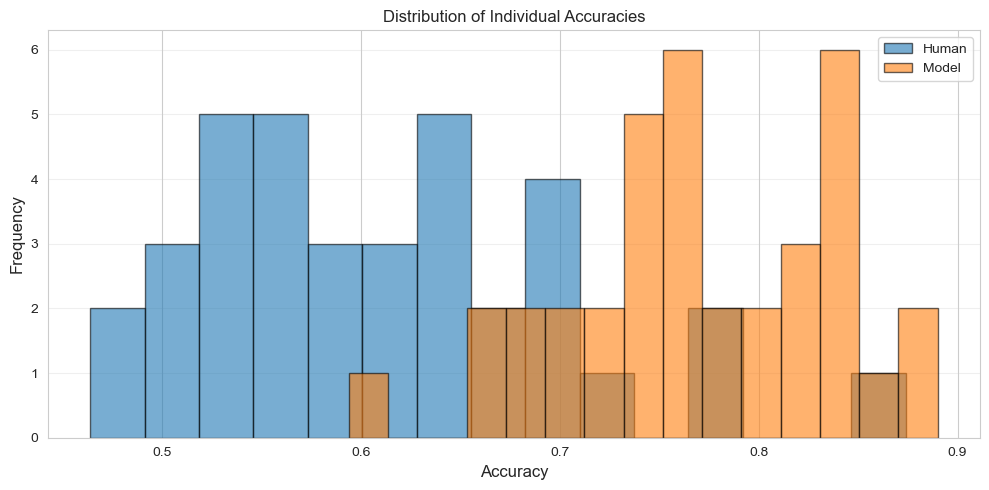

✓ Saved: accuracy-distribution.pdf


In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

for domain in ["Human", "Model"]:
    df = indiv_all[indiv_all["domain"] == domain]
    ax.hist(
        df["accuracy"],
        bins=15,
        alpha=0.6,
        label=domain,
        edgecolor="black"
    )

ax.set_xlabel("Accuracy", fontsize=12)
ax.set_ylabel("Frequency", fontsize=12)
ax.set_title("Distribution of Individual Accuracies", fontsize=12)
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(paths.outputs_dir / "accuracy-distribution.pdf", bbox_inches="tight")
plt.show()

print("✓ Saved: accuracy-distribution.pdf")

## 5. d' (Discriminability) by Domain and Condition

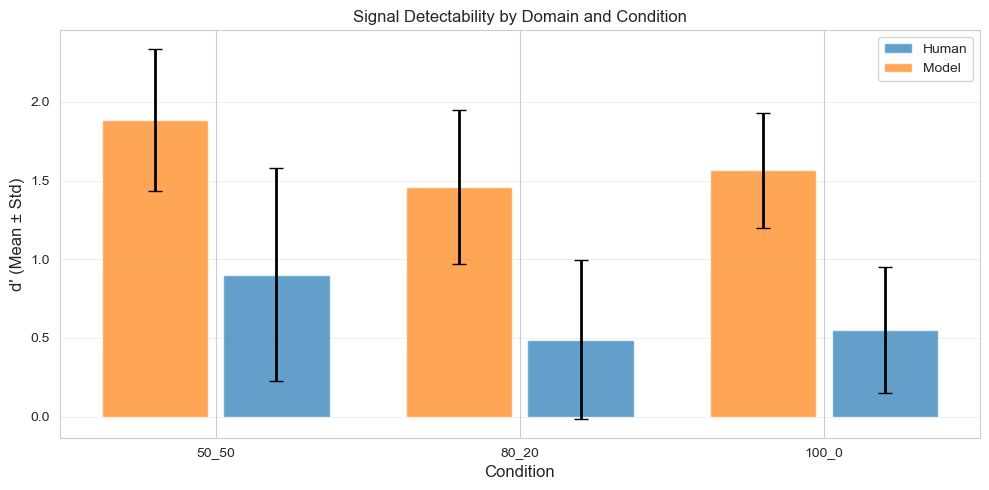

✓ Saved: dprime-by-condition.pdf


In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

for domain in ["Human", "Model"]:
    df = indiv_all[indiv_all["domain"] == domain]
    
    means = df.groupby("condition")["dprime"].mean()
    stds = df.groupby("condition")["dprime"].std()
    
    x = np.arange(len(means))
    offset = 0.2 if domain == "Human" else -0.2
    
    ax.bar(
        x + offset,
        means,
        width=0.35,
        label=domain,
        alpha=0.7,
        yerr=stds,
        capsize=5,
        error_kw={"elinewidth": 2}
    )

ax.set_xticks(np.arange(3))
ax.set_xticklabels(["50_50", "80_20", "100_0"])
ax.set_xlabel("Condition", fontsize=12)
ax.set_ylabel("d' (Mean ± Std)", fontsize=12)
ax.set_title("Signal Detectability by Domain and Condition", fontsize=12)
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(paths.outputs_dir / "dprime-by-condition.pdf", bbox_inches="tight")
plt.show()

print("✓ Saved: dprime-by-condition.pdf")

## 6. Outlier Detection

Identify strong and weak performers relative to domain mean.

In [7]:
def find_outliers(df, domain_name, threshold=1.5):
    """Find accuracy outliers (>1.5 std from mean)."""
    domain_df = df[df["domain"] == domain_name]
    mean_acc = domain_df["accuracy"].mean()
    std_acc = domain_df["accuracy"].std()
    
    lower_bound = mean_acc - threshold * std_acc
    upper_bound = mean_acc + threshold * std_acc
    
    outliers_low = domain_df[domain_df["accuracy"] < lower_bound]
    outliers_high = domain_df[domain_df["accuracy"] > upper_bound]
    
    return outliers_low, outliers_high, mean_acc, std_acc

for domain in ["Human", "Model"]:
    low, high, mean_acc, std_acc = find_outliers(indiv_all, domain)
    
    print(f"\n{domain}:")
    print(f"  Mean accuracy: {mean_acc:.3f} ± {std_acc:.3f}")
    print(f"\n  Strong performers (>+1.5σ):")
    if len(high) > 0:
        for _, row in high.iterrows():
            print(f"    {row['participantID']:20s} {row['condition']:6s} acc={row['accuracy']:.3f}")
    else:
        print("    (none)")
    
    print(f"\n  Weak performers (<-1.5σ):")
    if len(low) > 0:
        for _, row in low.iterrows():
            print(f"    {row['participantID']:20s} {row['condition']:6s} acc={row['accuracy']:.3f}")
    else:
        print("    (none)")


Human:
  Mean accuracy: 0.611 ± 0.092

  Strong performers (>+1.5σ):
    AG                   100_0  acc=0.775
    KM                   100_0  acc=0.789
    UR                   100_0  acc=0.874

  Weak performers (<-1.5σ):
    CY                   50_50  acc=0.470
    AZ                   50_50  acc=0.464

Model:
  Mean accuracy: 0.770 ± 0.067

  Strong performers (>+1.5σ):
    0responses_gemini-2.5-pro 100_0  acc=0.890

  Weak performers (<-1.5σ):
    0responses_claude-3-5-haiku-20241022 50_50  acc=0.594


## 7. Save Results

In [8]:
indiv_all.to_csv(paths.outputs_dir / "individual-differences.csv", index=False)
print(f"✓ Saved: individual-differences.csv")

✓ Saved: individual-differences.csv
